# Binary Population Codes

These exercises prepare you for the session on state-space-models. You will work with binary spike train data from 3 simultaneously recorded neurons and compute the statistics that the Ising model is designed to capture.

## Setup

### Import Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

## Working with Binary Spike Representations

In state space analysis, we often work with binary representations of spike trains. A binary representation means that we only care about whether or not a neuron fired in a given bin. In NumPy, we can compare the array against a value (e.g. `X >= 1`) to get a boolean array that is `True` (1) where that condition is met and `False` (0) otherwise. We can also combine such arrays to find points where both arrays are `True` (e.g. `X1 & X2`) or where at least one of them is `True`. In this section you are going to practice working with such binary spike train representations.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`counts >= 1`** | Create a boolean array that is `True` wherever at least one spike occurred |
| **`counts[:, i]`** | Select all time bins for neuron `i` |
| **`X.sum()`** | Count how many `True` / 1 entries are in a binary array |
| **`X.mean()`** | Compute the fraction of entries that are `True` / 1 |
| **`X1 & X2`** | Logical AND: `True` only where both arrays are `True` |
| **`X1 \| X2`** | Logical OR: `True` where at least one array is `True` |
| **`len(X)`** | Number of time bins in a 1D binary array |
| **`(counts >= 1).astype(int)`** | Convert a boolean spike mask to 0/1 integers |

### Exercises

Please fill in the blank cells with working code, according to each exercise below.  

*Note*: **"Example"** exercises already have the solutions, and will help show how the code is used for the exercises that follow.

**Setup:** We create synthetic data: 3 neurons, 1000 time bins of 10 ms each (= 10 s recording). Neurons 1 and 2 share a weak common input, making them slightly correlated. `counts` is an array of bins x neurons, where each entry is the number of spikes.

In [3]:
np.random.seed(42)
T = 1000
counts = np.zeros((T, 3), dtype=int)
counts[:, 0] = np.random.poisson(0.20, T)   # ~20 Hz
counts[:, 1] = np.random.poisson(0.25, T)   # ~25 Hz
counts[:, 2] = np.random.poisson(0.15, T)   # ~15 Hz
common = np.random.poisson(0.05, T)         # shared input to neurons 1 and 2
counts[:, 1] += common
counts[:, 2] += common

print(f"Data shape: {counts.shape}  (time bins x neurons)")
print(f"Mean spike counts per bin: {counts.mean(axis=0).round(3)}")

Data shape: (1000, 3)  (time bins x neurons)
Mean spike counts per bin: [0.201 0.285 0.186]


**Example**: Convert `counts` to a binary array that is 1 for every bin and neuron where at least one spike was observed. Sum X to count the total number of bins with spikes observed.

In [4]:
X = (counts >= 1)
X.sum()

np.int64(599)

**Exercise**: Convert `counts` to a binary array that is 1 for every bin and neuron where at least two spikes was observed. Sum X to count the total number of bins with spikes observed.

In [5]:
X = (counts >= 2)
X.sum()

np.int64(68)

**Exercise**: Convert the counts for neuron one (i.e. `counts[:,0]`) to a binary array and compute the number of bins where that neuron fired.

In [6]:
X = (counts[:, 0] >= 1)
X.sum()

np.int64(175)

**Exercise**: Convert the counts for neuron two (i.e. `counts[:,1]`) to a binary array and compute the number of bins where that neuron fired.

In [7]:
X = (counts[:, 1] >= 2)
X.sum()

np.int64(27)

**Example**: Create a binary array that is 1 only when the bin contained a spike in neuron 1 **AND** neuron 2 and sum to count the number of bins where both neurons fired.

In [8]:
X1 = (counts[:, 0] >= 1)
X2 = (counts[:, 1] >= 1)

X = (X1 & X2)
X.sum()

np.int64(33)

**Exercise**: Create a binary array that is 1 only when the bin contained a spike in neuron 2 **AND** neuron 3. Do these neurons fire together more often?
Didi: yes, they fire almost twice as often than neurons 1 and 2.


In [9]:
X2 = (counts[:, 1] >= 1)
X3 = (counts[:, 2] >= 1)

X = (X2 & X3)
X.sum()

np.int64(61)

**Example**: Get the number of trials where neurons in `X1` OR `X2` are active and divide by the length of X to get the fraction of bins where any of the two neurons fired.

In [11]:
(X1 | X2).sum() / len(X)

np.float64(0.398)

**Exercise**: Using the approach from above, get the fraction of bins where any of the three neurons fired.

In [12]:
(X1 | X2 | X3).sum() / len(X)

np.float64(0.484)

**Exercise**: Subtract the number of bins where any neuron fired from the total number of bins to calculate the fraction of bins where all neurons are silent.

In [13]:
AtLeastOneSpike = (X1 | X2 | X3).sum()
(len(X) - AtLeastOneSpike)/len(X)

np.float64(0.516)

## Counting the Occurrences of Binary Words

Instead of combining individual binary spike trains we can also treat each bin as a **binary word**: a vector of 0s and 1s indicating which neurons fired. A neuron’s entry is 1 if it fired *at least once* in that bin, otherwise 0. With N = 3 neurons there are $2^3 = 8$ possible words: `[0,0,0]`, `[1,0,0]`, ..., `[1,1,1]`. The probability distribution over these 8 words is the central object the Ising model is designed to fit.

In this section you are going to compute the probability for the different binary words in the data and finally represent them in a bar chart.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`X = (counts >= 1).astype(int)`** | Convert spike counts into binary words with shape `(time bins, neurons)` |
| **`word = [0, 0, 0]`** | Store one binary word to search for |
| **`np.all(X == word, axis=1)`** | Find the time bins where all neuron entries match `word` |
| **`np.all(X == word, axis=1).sum()`** | Count how often `word` occurs in the data |
| **`word_count / len(X)`** | Convert one word count into an empirical probability |
| **`word_counts / len(X)`** | Convert all word counts into empirical probabilities |
| **`plt.bar(labels, word_probabilities)`** | Plot the empirical word distribution as a bar chart |

### Exercises

**Example**: Compute the probability for the occurrence of the binary word `[0, 0, 0]` (i.e all neurons are silent).

In [14]:
X = (counts >= 1).astype(int)
word = [0, 0, 0]

word_count = np.all(X == word, axis=1).sum()
word_prob = word_count / len(X)

word_prob

np.float64(0.516)

**Exercise**: Compute the probability for the occurrence of the word `[1, 1, 1]` (i.e. all neurons are firing).

In [15]:
X = (counts >= 1).astype(int)
word = [1, 1, 1]

word_count = np.all(X == word, axis=1).sum()
word_prob = word_count / len(X)

word_prob

np.float64(0.006)

**Exercise**: Compute the probability for the binary word that represents neuron 1 and 3 are firing.

In [16]:
X = (counts >= 1).astype(int)
word = [1, 0, 1]

word_count = np.all(X == word, axis=1).sum()
word_prob = word_count / len(X)

word_prob

np.float64(0.021)

**Exercise**: The code below computes all possible binary words. Convert the `word_counts` to a probability and run the last cell to plot them as a bar chart.

In [17]:
all_words = np.array(list(itertools.product([0, 1], repeat=3)))  # shape (8, 3)
labels = [str(np.array(w)) for w in all_words]
word_counts = np.array([np.all(X == w, axis=1).sum() for w in all_words])

In [18]:
all_words

array([[0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 1, 0],
       [1, 1, 1]])

In [19]:
word_probabilities = word_counts / len(X)

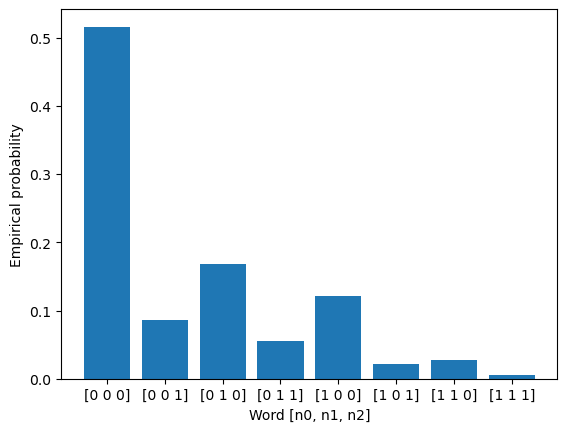

In [20]:
plt.bar(labels, word_probabilities)
plt.xlabel('Word [n0, n1, n2]')
plt.ylabel('Empirical probability');

## Computing Co-Firing Rates

The Ising model is fitted to statistics measured from the binary spike data. For each neuron, we first compute its firing rate: the fraction of time bins in which that neuron fired. Then we compute pairwise co-firing rates: the fraction of time bins in which two neurons fired together.

These quantities are called expectation parameters and are usually written as $\eta$. For three neurons, we use:

$$
\eta = [\eta_0, \eta_1, \eta_2, \eta_{01}, \eta_{02}, \eta_{12}]
$$

where $\eta_i = P(X_i = 1)$ is the firing rate of neuron $i$, and $\eta_{ij} = P(X_i = 1, X_j = 1)$ is the co-firing rate of neurons $i$ and $j$.

In this section, you will compute these values directly from the binary spike matrix `X`.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`(counts >= 1).astype(int)`** | Convert spike counts to binary 0/1 words |
| **`X.mean(axis=0)`** | Compute marginal firing rates $\eta_i$ for all neurons |
| **`X[:, i]`** | Select the binary spike train for neuron `i` |
| **`X[:, i] * X[:, j]`** | Binary co-activation array for neurons `i` and `j` |
| **`(X[:, i] * X[:, j]).mean()`** | Compute the pairwise rate $\eta_{ij}$ |

### Exercises

Create a binary representation of the spike counts and convert it to integers. This allows us to combine the arrays with multiplication.

In [25]:
X = (counts >= 1).astype(int)
X.shape

(1000, 3)

**Exercise:** Compute the three marginal firing rates $\eta_i$ from `X` (i.e. the mean along the first axis). Do they match the rates you would expect from the setup cell?

In [21]:
eta_marginal = np.mean(X, axis=0)
eta_marginal

array([0.175, 0.256, 0.168])

**Example:** Compute the pairwise rate $\eta_{ij}$ for neurons 1 and 2.

In [27]:
eta_pair = (X[:, 0] * X[:,1]).mean()
eta_pair

np.float64(0.033)

**Exercise:** Compute the pairwise rate $\eta_{ij}$ for neurons 2 and 3.

In [29]:
eta_pair = (X[:, 1] * X[:,2]).mean()
eta_pair

np.float64(0.061)

**Example:** Compute the pairwise rate $\eta_{ij}$ for all three pairs.

In [30]:
pairs = [(0, 1), (0, 2), (1, 2)]
eta_pair = np.array([(X[:, i] * X[:, j]).mean() for i, j in pairs])
eta_pair

array([0.033, 0.027, 0.061])

**Exericse**: Using the same pattern as above compute $\eta_{ij}$ under the assumption that the neurons are independent (**Hint**: compute $\eta_{ij}$ under the independence assumption for neurons 1 and 2 as `eta_marginal[0] * eta_marginal[1]`).

In [ ]:
eta_marginal[0] * eta_marginal[1]


np.float64(0.0448)

**Exercise**: Subtract the $\eta_{ij}$ values under the independence assumption from the actually observed values of $\eta_{ij}$ to see how the observations are deviating from the assumption.

array([-0.0118  , -0.0024  ,  0.017992])

## The Ising Model Distribution

The Ising model assigns a probability to each binary word $\mathbf{x}$ by computing an energy (or also called score) and normalizing. The energy of a word $\mathbf{x} = [x_0, x_1, x_2]$ is the dot product $\theta \cdot f(\mathbf{x})$, where $f(\mathbf{x})$ records which neurons fired and which pairs co-fired:

$$f(\mathbf{x}) = [x_0,\ x_1,\ x_2,\ x_0 x_1,\ x_0 x_2,\ x_1 x_2]$$

The first three entries say which neurons were active; the last three say which pairs co-fired. The parameter vector $\theta = [\theta_0, \theta_1, \theta_2, \theta_{01}, \theta_{02}, \theta_{12}]$ weights each entry: a large positive $\theta_i$ makes neuron $i$ fire often; a large positive $\theta_{ij}$ makes the pair $(i, j)$ co-fire often.

To turn energies into probabilities we exponentiate and divide by the partition function $Z$, which sums over all 8 words so the probabilities add up to 1:

$$P(\mathbf{x}) = \frac{\exp(\theta \cdot f(\mathbf{x}))}{Z}, \qquad Z = \sum_{\mathbf{x}} \exp(\theta \cdot f(\mathbf{x}))$$

Notice that by design $f(\mathbf{x})$ has the same structure as $\eta$ from the section above. At the fitted parameters, the model's expected $f(\mathbf{x})$ matches the empirical $\eta$ exactly.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`np.array([x[0], x[1], x[2], x[0]*x[1], x[0]*x[2], x[1]*x[2]])`** | Sufficient statistic of a single word |
| **`F @ theta`** | Energies for all 8 words at once, shape `(8,)` |
| **`np.exp(energies).sum()`** | Partition function $Z$ |
| **`np.exp(energies) / Z`** | Normalized model probabilities, shape `(8,)` |

### Exercises

**Example:** Compute $f(\mathbf{x})$ for the word $[1, 0, 1]$ (neurons 1 and 3 fired; neuron 2 was silent).

The formula gives:
$$f([1,0,1]) = [x_0, x_1, x_2, x_0 x_1, x_0 x_2, x_1 x_2] = [1, 0, 1, 0, 1, 0]$$

The pair $(0, 2)$ co-fired (both active), so its entry is 1. The other pairs include at least one silent neuron, so their entries are 0.

In [32]:
x = np.array([1, 0, 1])
fx = np.array([x[0], x[1], x[2], x[0]*x[1], x[0]*x[2], x[1]*x[2]])
print('Word:  ', x)
print('f(x):  ', fx)

Word:   [1 0 1]
f(x):   [1 0 1 0 1 0]


**Exercise:** Compute $f(\mathbf{x})$ for the word $[0, 1, 1]$ (neurons 2 and 3 fired; neuron 1 was silent).


In [33]:
x = np.array([0, 1, 1])
fx = np.array([x[0], x[1], x[2], x[0]*x[1], x[0]*x[2], x[1]*x[2]])
print('Word:  ', x)
print('f(x):  ', fx)

Word:   [0 1 1]
f(x):   [0 1 1 0 0 1]


**Demo**: Now build $F$ (the sufficient statistic) for all 8 words at once. Using `all_words` from Section 1, construct an `(8, 6)` array where each row is `[x0, x1, x2, x0*x1, x0*x2, x1*x2]`.

In [34]:
all_words = np.array(list(itertools.product([0, 1], repeat=3)))  # shape (8, 3)

F = np.column_stack([
    all_words[:, 0],
    all_words[:, 1],
    all_words[:, 2],
    all_words[:, 0] * all_words[:, 1],
    all_words[:, 0] * all_words[:, 2],
    all_words[:, 1] * all_words[:, 2],
])

print('F shape:', F.shape)
print('F =\n', F)

F shape: (8, 6)
F =
 [[0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [0 1 1 0 0 1]
 [1 0 0 0 0 0]
 [1 0 1 0 1 0]
 [1 1 0 1 0 0]
 [1 1 1 1 1 1]]


**Demo:** Use `F` from the example above and the `theta` given in the cell below to compute the Ising model probabilities $P(\mathbf{x})$ for all 8 words. Verify that the probabilities sum to 1, then plot `p_emp` and `p_model` side by side as a bar chart.

*In the live sessions, we will see how the EM algorithm finds the `theta` that makes `p_model` match `p_emp`.*

In [35]:
theta = np.array([0.5, -0.3, 0.1, 0.8, -0.2, 0.4])  # [biases, couplings] — not yet fitted

Sum of p_model: 1.0


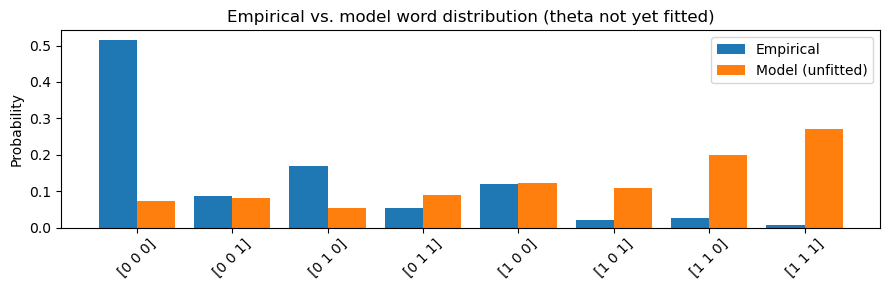

In [36]:
energies = F @ theta
Z = np.exp(energies).sum()
p_model = np.exp(energies) / Z
print('Sum of p_model:', p_model.sum().round(6))

# Plot empirical vs model
x_pos = np.arange(8)
width = 0.4
plt.figure(figsize=(9, 3))
plt.bar(x_pos - width/2, word_probabilities,   width, label='Empirical')
plt.bar(x_pos + width/2, p_model, width, label='Model (unfitted)')
plt.xticks(x_pos, labels, rotation=45)
plt.ylabel('Probability')
plt.title('Empirical vs. model word distribution (theta not yet fitted)')
plt.legend()
plt.tight_layout()
plt.show()